In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
df =  pd.read_csv('rolling_stones_spotify.csv')
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [48]:
increasing = df['Unnamed: 0'].is_monotonic_increasing
print('Column Unnamed:0 is monotonus inceasing:',increasing)
if increasing:
    df.drop('Unnamed: 0',axis=1, inplace=True)
df.head()

Column Unnamed:0 is monotonus inceasing: True


,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [49]:
df_clean = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['name']).sort_index()
print(f"\nTotal rows after removing duplicate song names: {df_clean.shape[0]}")
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], format='mixed')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean.head()


Total rows after removing duplicate song names: 954


,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640,2022
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173,2022
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160,2022
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880,2022
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106,2022


## Feature Engineering

Since id and uri will not having any impact on similarity beyween songs so we can remove them from analysis

In [50]:
id = df_clean['id']
uri = df_clean['uri']
df_clean.drop(['id','uri'],axis = 1, inplace = True)
df_clean.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640,2022
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173,2022
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160,2022
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880,2022
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106,2022


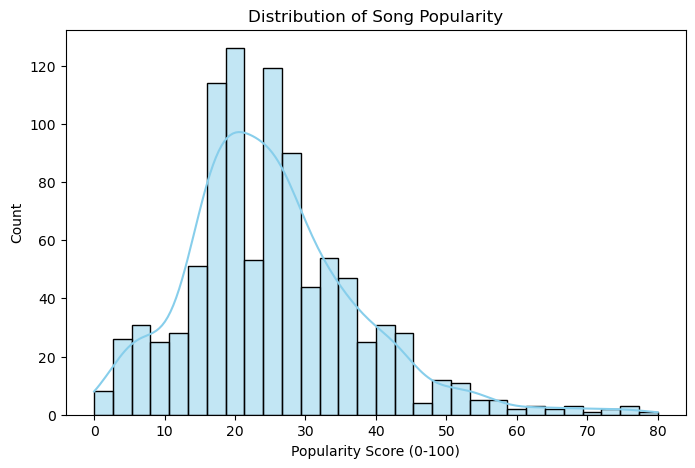

In [51]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['popularity'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Count')
plt.show()

--- Top 2 Albums based on Highest Number of Popular Songs ---
album
Goats Head Soup (Deluxe)    28
Live At The El Mocambo      23
Name: name, dtype: int64


/var/folders/kv/329nwfzj7vb086btrz5x67l00000gn/T/ipykernel_15715/692818685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=album_popularity_counts.head(10).values, y=album_popularity_counts.head(10).index, palette='viridis')


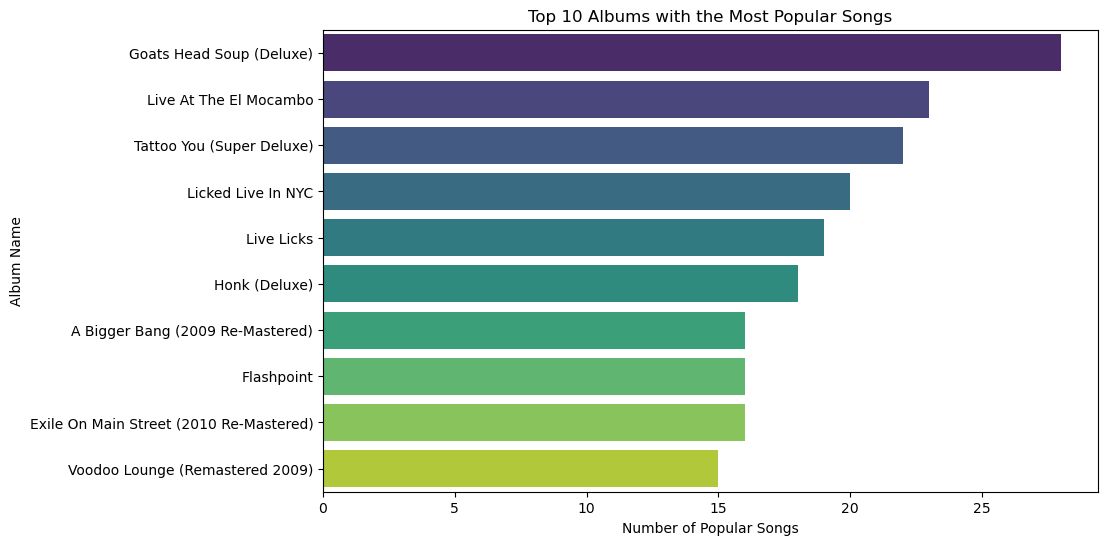

In [ ]:
popularity_threshold = 20
popular_songs = df_clean[df_clean['popularity'] >= popularity_threshold]
album_popularity_counts = popular_songs.groupby('album')['name'].count().sort_values(ascending=False)
top_2_albums = album_popularity_counts.head(2)
print("--- Top 2 Albums based on Highest Number of Popular Songs ---")
print(top_2_albums)
plt.figure(figsize=(10, 6))
sns.barplot(x=album_popularity_counts.head(10).values, y=album_popularity_counts.head(10).index, palette='viridis')
plt.title('Top 10 Albums with the Most Popular Songs')
plt.xlabel('Number of Popular Songs')
plt.ylabel('Album Name')
plt.show()

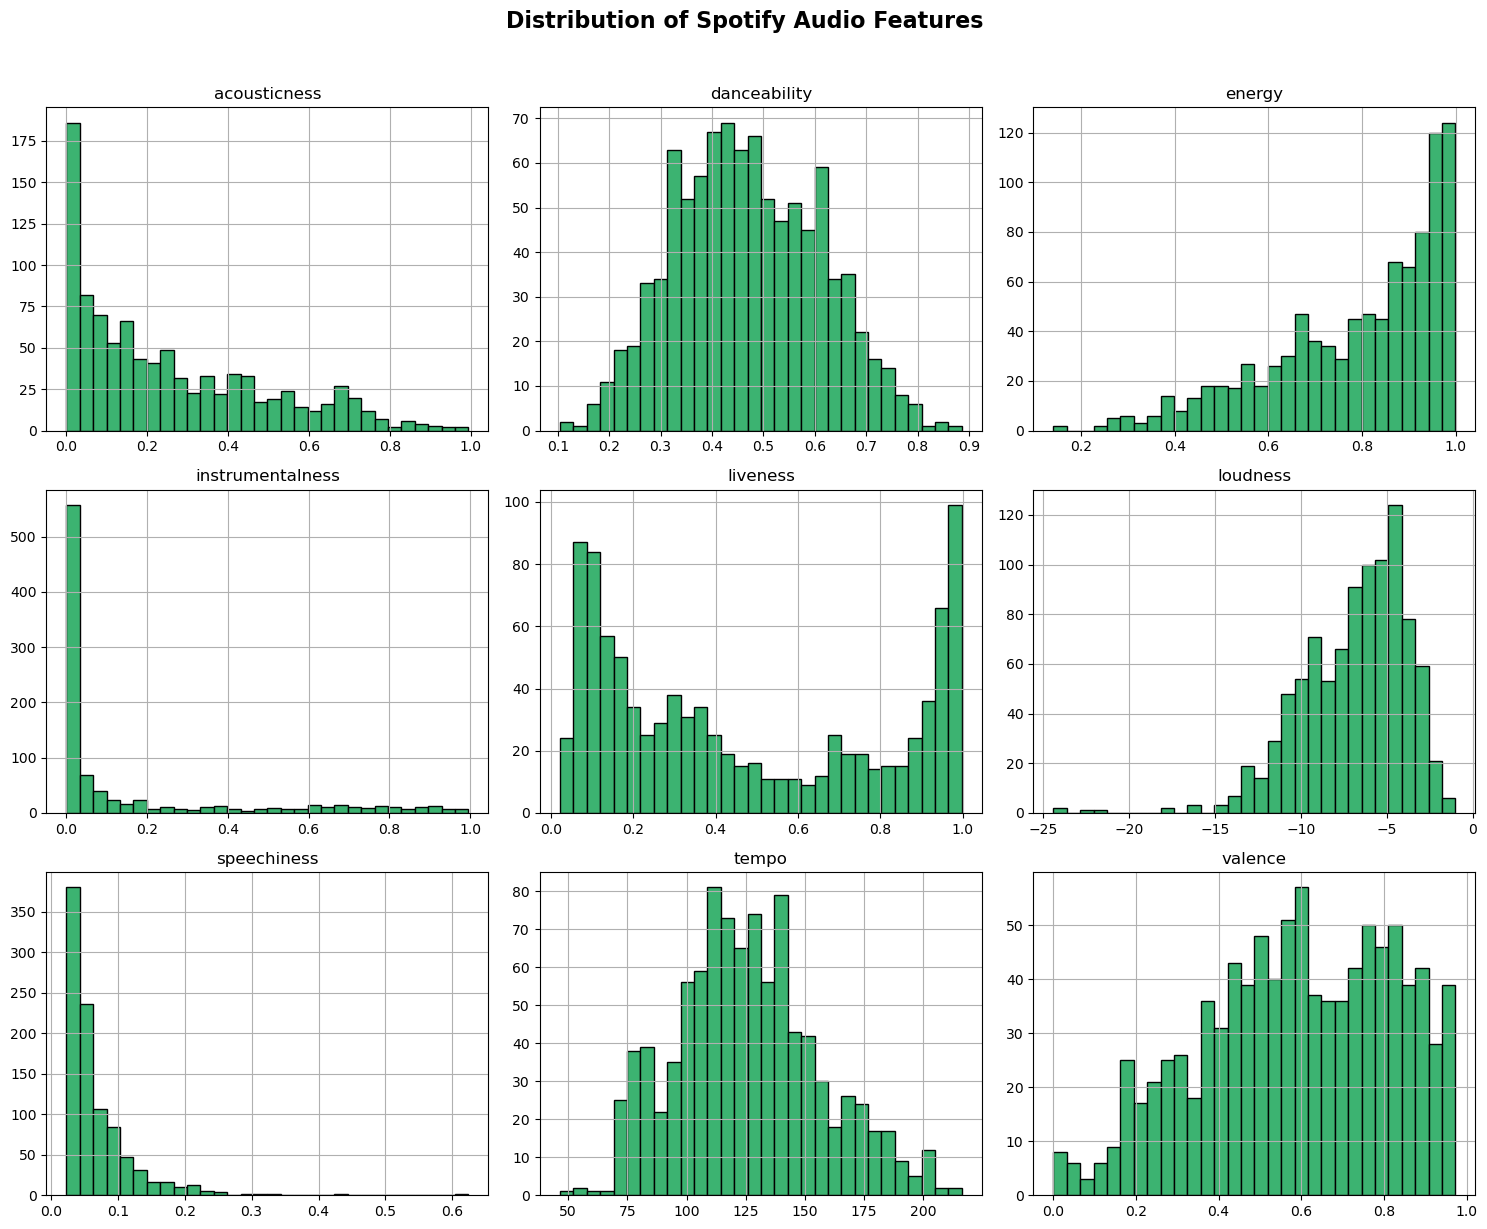

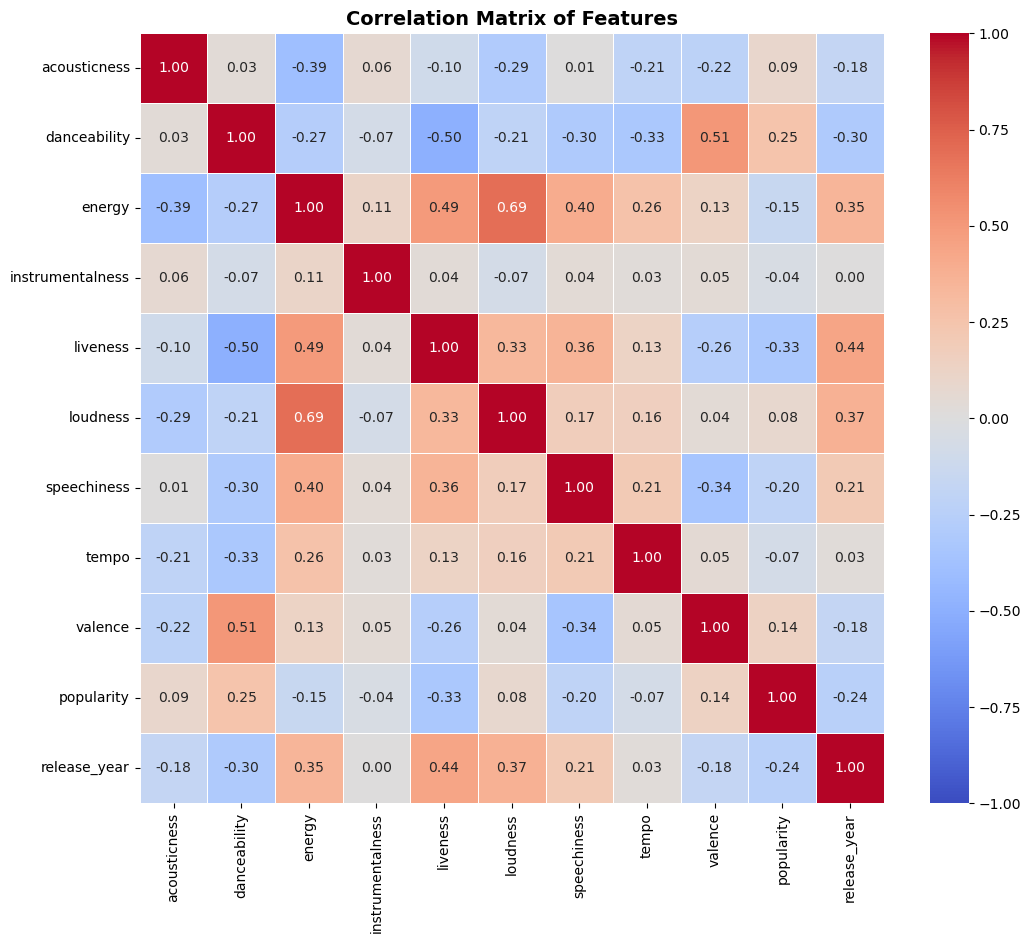

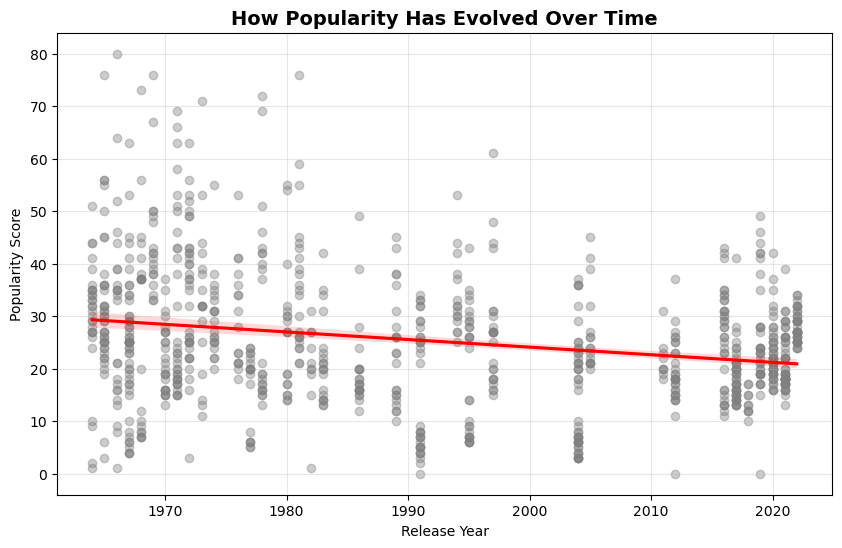

In [ ]:
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
]

df_clean[audio_features].hist(figsize=(15, 12), bins=30, edgecolor='black', color='mediumseagreen')
plt.suptitle('Distribution of Spotify Audio Features', y=1.02, size=16, weight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
correlation_data = df_clean[audio_features + ['popularity', 'release_year']]
correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features', size=14, weight='bold')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='release_year', y='popularity', data=df_clean, 
            scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red'})
plt.title('How Popularity Has Evolved Over Time', size=14, weight='bold')
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.grid(alpha=0.3)
plt.show()


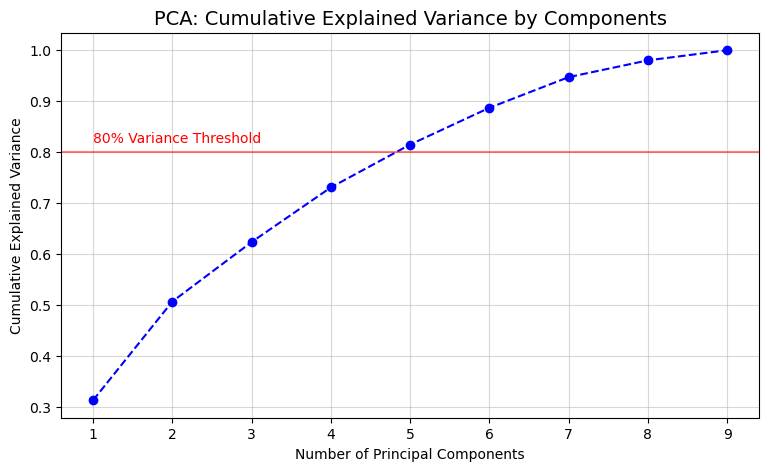

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[audio_features])

pca = PCA()
pca.fit(scaled_features)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle='-', alpha=0.5)
plt.text(1, 0.82, '80% Variance Threshold', color='red', fontsize=10)

plt.title('PCA: Cumulative Explained Variance by Components', size=14)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, len(audio_features) + 1))
plt.grid(True, alpha=0.5)
plt.show()


In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Optimal PCA components for 80% variance: {n_components}")

pca = PCA(n_components=n_components)
pca_features = pca.fit_transform(scaled_features)


Optimal PCA components for 80% variance: 5


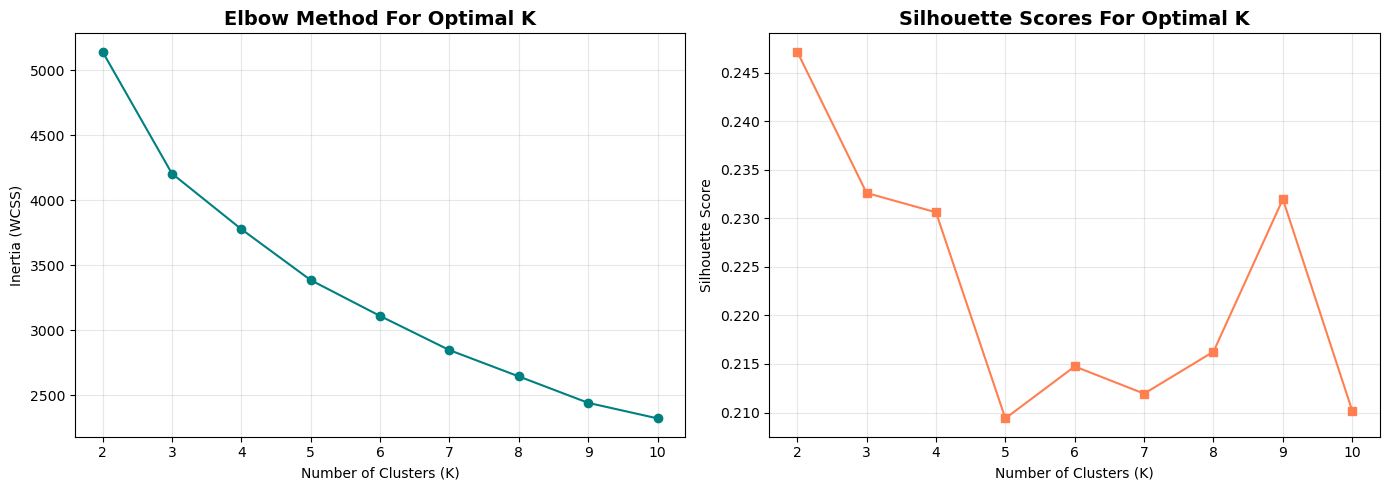

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
K_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(pca_features)
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(pca_features, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linestyle='-', color='teal')
plt.title('Elbow Method For Optimal K', size=14, weight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='coral')
plt.title('Silhouette Scores For Optimal K', size=14, weight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
optimal_k = 5

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_kmeans.fit(pca_features)

df_clean['cluster'] = final_kmeans.labels_

print(f"--- Songs Distributed Across {optimal_k} Clusters ---")
print(df_clean['cluster'].value_counts().sort_index())


--- Songs Distributed Across 5 Clusters ---
cluster
0    223
1    281
2    146
3    197
4    107
Name: count, dtype: int64


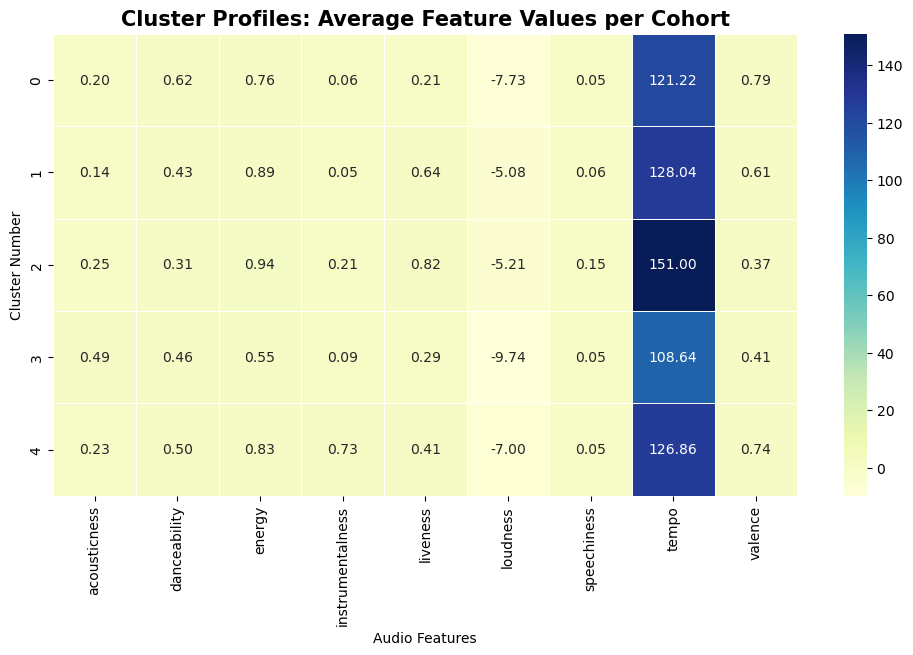

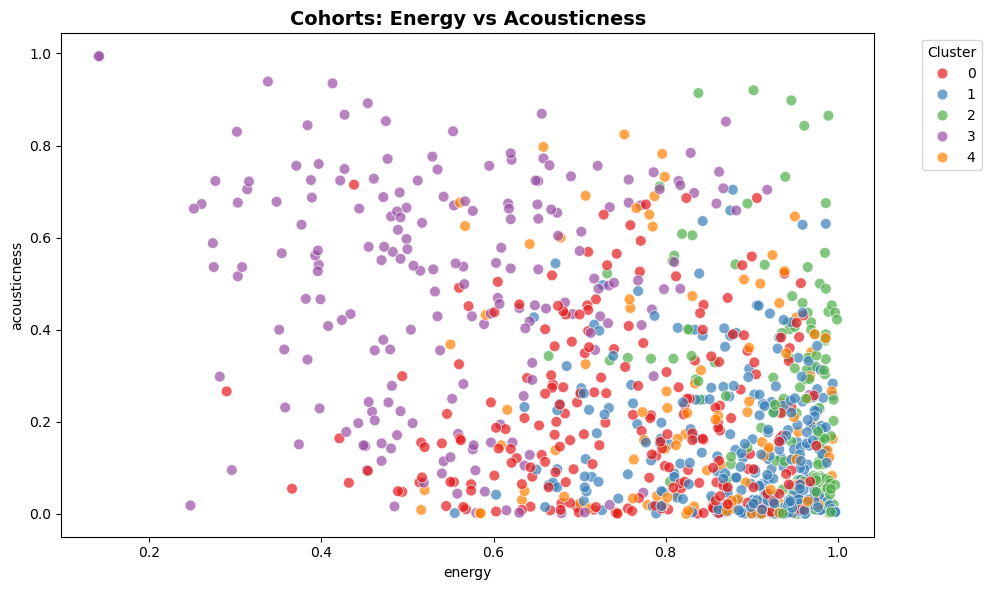

In [ ]:
cluster_profiles = df_clean.groupby('cluster')[audio_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Cluster Profiles: Average Feature Values per Cohort', size=15, weight='bold')
plt.ylabel('Cluster Number')
plt.xlabel('Audio Features')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='energy', 
    y='acousticness', 
    hue='cluster', 
    palette='Set1', 
    data=df_clean, 
    alpha=0.7, 
    s=60
)
plt.title('Cohorts: Energy vs Acousticness', size=14, weight='bold')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
print("--- Cluster Descriptions ---")
for i in range(optimal_k):
    cluster_data = df_clean[df_clean['cluster'] == i]
    
    print(f"\nCohort {i} Analysis (Size: {len(cluster_data)} songs):")
    
    top_songs = cluster_data.sort_values('popularity', ascending=False).head(3)['name'].tolist()
    print(f"Top Examples: {', '.join(top_songs)}")

    means = cluster_profiles.loc[i].sort_values(ascending=False)
    print(f"Dominant Audio Traits: High {means.index[0]}, High {means.index[1]}, High {means.index[2]}")


--- Cluster Descriptions ---

Cohort 0 Analysis (Size: 223 songs):
Top Examples: Start Me Up - Remastered 2009, (I Can't Get No) Satisfaction - Mono Version, Sympathy For The Devil - 50th Anniversary Edition
Dominant Audio Traits: High tempo, High valence, High energy

Cohort 1 Analysis (Size: 281 songs):
Top Examples: Paint It, Black, Shine A Light, Doo Doo Doo Doo Doo (Heartbreaker)
Dominant Audio Traits: High tempo, High energy, High liveness

Cohort 2 Analysis (Size: 146 songs):
Top Examples: Time Is On My Side - Mono Version / Organ Intro, Like A Rolling Stone - Live / Remastered 2009, Hate To See You Go
Dominant Audio Traits: High tempo, High energy, High liveness

Cohort 3 Analysis (Size: 197 songs):
Top Examples: Gimme Shelter, Angie, Wild Horses - 2009 Mix
Dominant Audio Traits: High tempo, High energy, High acousticness

Cohort 4 Analysis (Size: 107 songs):
Top Examples: Tumbling Dice, Get Off Of My Cloud - Mono Version, The Last Time - Mono Version
Dominant Audio Traits: Hig